> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy numpy pandas


In [ ]:
# Fetch this case's data files when they are not already next to the notebook.
import os, urllib.parse, urllib.request
BASE = 'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/notebooks/zh/Sudoku_Game/'
FILES = [
    'sudoku.csv',
]
for f in FILES:
    if not os.path.exists(f):
        os.makedirs(os.path.dirname(f) or '.', exist_ok=True)
        urllib.request.urlretrieve(BASE + urllib.parse.quote(f), f)
print(len(FILES), 'data file(s) ready')

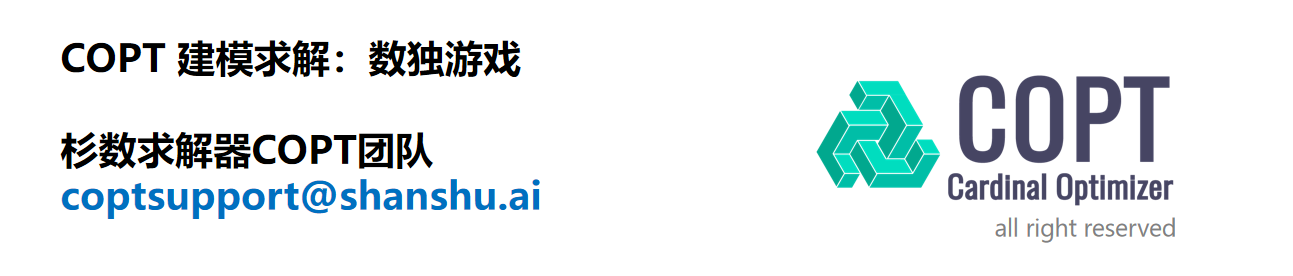

# 数独游戏代码实现

## 使用COPT建模求解数独游戏的步骤

1. **导入COPT-Python接口库** `coptpy`

2. 添加/导入模型**数据**

3. 创建**求解环境**和求解**模型**

4. **构建模型：依次添加三要素**
    - **决策变量**：整数型（0-1型）
    - **目标函数**
    - **约束条件**：
      - 棋盘赋初值
      - 每个网格$(i,j)$内必须且只能填写一个数字
      - 每行（$i\in \{1, ..., 9\}$）中数字k只能出现1次
      - 每一列（$j\in \{1, ..., 9\}$）中数字k只能出现1次
      - 每个宫内数字k只能出现1次字

6. **求解**

7. 查看和分析求解**结果**

## 1. 导入coptpy和第三方包

In [1]:
# 导入第三方包
from coptpy import *
import numpy as np
import pandas as pd

`pandas`用来读取棋盘初始化的外部数据（`pandas.read_csv()`），`numpy`用来构造稀疏矩阵表示棋盘（`np.zeros(shape, dtype)`）

## 2. 棋盘初始化

**（1）棋盘规模：**

$$
\begin{aligned}
&整个数独棋盘的大小:9\times 9\\
&宫的规模：3\times 3 \\
\end{aligned}
$$

**（2）构建棋盘，网格赋初值：读入初始数据**

调用`pd.read_csv(filename, dtype)`读入外部数据，存储在`DataFrame`对象`sudoku_info`中。

In [3]:
# 数独棋盘初始化
sudoku_info = pd.read_csv('sudoku.csv', dtype=int)
sudoku_info.head(10)

,row,col,value
0,0,5,2
1,0,6,9
2,0,7,3
3,1,7,1
4,1,8,5
5,2,1,4
6,2,2,6
7,2,8,7
8,3,1,6
9,3,3,8


`sudoku_info`中包含数独棋盘的初始赋值信息，表格中每一行表示：网格(row,col)的初始数字value，未出现的网格没有初始赋值。举例说明：

|row|col|value|
|---|---|---|
|0|5|2|
|0|6|9|

网格(0,5)的初始赋值为数字2，网格(0,6)的初始赋值为数字9.

构造一个9X9的**稀疏矩阵**`SUDOKU_BOARD`来表示初始的数独棋盘，矩阵的元素基于`sudoku_info`生成。
其中，在`sudoku_info`中出现的坐标(row, col)取值为对应的value，未在`sudoku_info`中出现的坐标取默认值0。

`DataFrame.iterrows()`是对`DataFrame`中的行(Rows)进行迭代的生成器，返回每行的**索引(idx)** 以及一个 **包含行本身的对象(r)**。

In [5]:
# build 9x9 matrix 
SUDOKU_BOARD = np.zeros([9, 9], dtype=int)
for idx,r in sudoku_info.iterrows():
    print("index{0}:({1},{2})={3}".format(idx, r['row'], r['col'], r['value']))
    SUDOKU_BOARD[r['row'], r['col']] = r['value']
    

index0:(0,5)=2
index1:(0,6)=9
index2:(0,7)=3
index3:(1,7)=1
index4:(1,8)=5
index5:(2,1)=4
index6:(2,2)=6
index7:(2,8)=7
index8:(3,1)=6
index9:(3,3)=8
index10:(3,5)=4
index11:(3,8)=9
index12:(4,2)=8
index13:(4,3)=1
index14:(4,5)=7
index15:(4,6)=6
index16:(5,0)=4
index17:(5,3)=2
index18:(5,5)=9
index19:(5,7)=5
index20:(6,0)=3
index21:(6,6)=2
index22:(6,7)=9
index23:(7,0)=7
index24:(7,1)=9
index25:(8,1)=2
index26:(8,2)=5
index27:(8,3)=3


<font color="#B22222">
<b>注意：</b>
</font>

和前面数学模型中$\forall i,j \in \{1, ..., 9\}$不同，代码实现时，在`sudoku_info` 和稀疏矩阵 `SUDOKU_BOARD` 中，由于下标的起始值为0，其中的`row`和`col`$\in\{0,1,\cdots,8\}$

In [7]:
print("初始数独棋盘：\n")
print(SUDOKU_BOARD)

初始数独棋盘：

[[0 0 0 0 0 2 9 3 0]
 [0 0 0 0 0 0 0 1 5]
 [0 4 6 0 0 0 0 0 7]
 [0 6 0 8 0 4 0 0 9]
 [0 0 8 1 0 7 6 0 0]
 [4 0 0 2 0 9 0 5 0]
 [3 0 0 0 0 0 2 9 0]
 [7 9 0 0 0 0 0 0 0]
 [0 2 5 3 0 0 0 0 0]]


**（3）展示初始棋盘：可视化工具**

通过`print_board(SUDOKU_BOARD)`，将二维数组`SUDOKU_BOARD`以更加美观清晰的方式呈现。

In [9]:
# 数独棋盘可视化工具
def print_board(board): 
    row, col = board.shape
    for i in range(row):
        print_row = ''
        for j in range(col):
            sep = ' ' if j%3 != 0 else'|'
            if board[i,j] == 0:
                print_row += '{}{}'.format(sep, '_')
            else:
                print_row += '{}{}'.format(sep, board[i,j])
        print_row += '|'
        print(print_row)
        if (i+1)%3 == 0 and i != row-1:
            print('-'*len(print_row))
        
print_board(SUDOKU_BOARD)

|_ _ _|_ _ 2|9 3 _|
|_ _ _|_ _ _|_ 1 5|
|_ 4 6|_ _ _|_ _ 7|
-------------------
|_ 6 _|8 _ 4|_ _ 9|
|_ _ 8|1 _ 7|6 _ _|
|4 _ _|2 _ 9|_ 5 _|
-------------------
|3 _ _|_ _ _|2 9 _|
|7 9 _|_ _ _|_ _ _|
|_ 2 5|3 _ _|_ _ _|


## 3. 创建COPT求解环境

In [11]:
# Create COPT environment
env = Envr()
# Create COPT model
model = env.createModel("sudoku")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 4. 构建模型

### 4.1 添加决策变量
$$
X_{ijk}\in \{0,1\},\qquad \forall i,j,k\in \{1, ..., 9\}
$$

调用`Model.addVars()`批量添加$X_{ijk}$，由于决策变量下标有三个维度：$i,j,k$，并且已知维度规模为$9\times9\times9$，所以通过指定变量下标规模的形式进行添加。同时，由于决策变量是0-1整数变量，指定参数`vtype=COPT.BINARY`，返回`tupledict`类对象。

In [13]:
# Add variables: x
x = model.addVars(9, 9, 9, vtype=COPT.BINARY)
print("模型中决策变量的数量：", model.getAttr(attrname="Cols"))

模型中决策变量的数量： 729


<font color="#B22222">
<b>注意：下标对应关系</b>
</font>

1. 调用`Model.addVars()`返回的`x`为`tupledict`类的对象，存储模型中的所有决策变量，起始下标为\[0,0,0\]；
2. 而我们在前面数学模型中定义的决策变量$X_{ijk},(\forall i,j,k\in \{1, ..., 9\})$，起始下标为(1,1,1)；
3. 二维稀疏矩阵SUDOKU_BOARD表示数独棋盘，起始下标为\[0,0\]，填写的数字取值为1~9。

如：$X_{111}=1 \Longleftrightarrow$ `x[0,0,0]=1` $\Longleftrightarrow SUDOKU\_BOARD[0,0]=1$，表示含义均为：棋盘网格(第一行第一列)填写数字1。

具体对应关系如下表：

|数学形式:$X_{ijk}$|COPT模型:`x`|二维矩阵|含义|
|:---:|:---:|:---:|:---:|
|$i$|$i-1$|$i-1$|行|
|$j$|$j-1$|$i-1$|列|
|$k$|$k-1$|$k$|网格内填写的数字|

$$
\forall i,j,k\in \{1, ..., 9\}
$$

### 4.2 添加约束条件
**（1）棋盘赋初值：若初始棋盘网格$(i,j)$给定数字k，则**
$$
X_{i,j,k} = 1
$$

二维稀疏矩阵`SUDOKU_BOARD`表示数独棋盘，其中`SUDOKU_BOARD[i][j]=0`表示网格$(i,j)$未赋初值，待填写数字；反之则表示网格$(i,j)$已有初始值$k$，决策变量`x[i,j,k]=1`。

In [15]:
# Fix variables associated with cells whose values are pre-specified
model.addConstrs(x[i,j,SUDOKU_BOARD[i][j] - 1] == 1 for i in range(9) for j in range(9) if SUDOKU_BOARD[i][j] != 0)
print("棋盘赋初值后约束条件数量：",model.getAttr("rows"))

棋盘赋初值后约束条件数量： 28


**（2）网格：每个网格$(i,j)$内必须且只能填写一个数字**
$$
\sum_{k=1}^9 X_{ijk} = 1,\qquad \forall i,j \in \{1, ..., 9\}
$$

In [17]:
## Each cell only takes one value
model.addConstrs(x.sum(i, j, "*") == 1 
                 for i in range(9)
                 for j in range(9))
print("添加网格约束后，约束条件数量：",model.getAttr("rows"))

添加网格约束后，约束条件数量： 109


在数独问题中，`tupledict.sum()`的优势体现非常明显，它可以使得约束添加变得清晰且方便。指定匹配模式`pattern=(i,j,"*")`,意味着我们固定网格坐标，将表示是否填写数字1～9的0-1变量 $X_{ijk} $相加。

对比另一种实现方式是3层循环嵌套的结构：
```python
model.addConstrs(quicksum(x[i,j,k] for k in range(9)) == 1 
                 for i in range(9)
                 for j in range(9))
```

**（3）行：每行（$i\in \{1, ..., 9\}$）中数字k只能出现1次**
$$
\sum_{j} X_{ijk} = 1,\qquad \forall i,k \in \{1, ..., 9\}
$$

In [19]:
# Each value appears once per row

model.addConstrs(x.sum(i, "*", k) == 1 
                 for i in range(9)
                 for k in range(9))
print("添加行约束后，模型约束条件数量：",model.getAttr("rows"))

添加行约束后，模型约束条件数量： 190


调用`tupledict.sum()`，指定匹配模式`pattern=(i,"*", k)`，表示指定行$i$和数字$k$，将0-1变量 $X_{ijk} $相加。

同样，若用`quicksum()`实现，需要三层循环嵌套，十分繁琐：
```python
model.addConstrs(quicksum(x[i,j,k] for j in range(9)) == 1 
                 for i in range(9)
                 for k in range(9))
```

**（4）列：每一列（$j\in \{1, ..., 9\}$）中数字k只能出现1次**
$$
\sum_{i} X_{ijk} = 1,\qquad \forall k,j \in \{1, ..., 9\}
$$

In [21]:
# Each value appears once per column

model.addConstrs(x.sum("*", j, k) == 1 
                 for j in range(9)
                 for k in range(9))
print("添加列约束后，模型约束条件数量：",model.getAttr("rows"))

添加列约束后，模型约束条件数量： 271


调用`tupledict.sum()`，指定匹配模式`pattern=("*",j, k)`，表示指定列和数字$k$，并将指定列中，数字$k$对应的0-1变量$X_{ijk} $相加。

同样，若用`quicksum()`实现，需要三层循环嵌套：
```python
model.addConstrs(quicksum(x[i,j,k] for i in range(9)) == 1 
                 for j in range(9)
                 for k in range(9))
```

**（5）宫：每个宫内数字k只能出现1次**
$$
\sum_{i\in \{3p, ..., 3(p+1)\},j\in \{3q, ..., 3(q+1)\}} X_{ijk} = 1,\qquad \forall p,q \in \{1, 2, 3\}, k\in\{1, ..., 9\}
$$

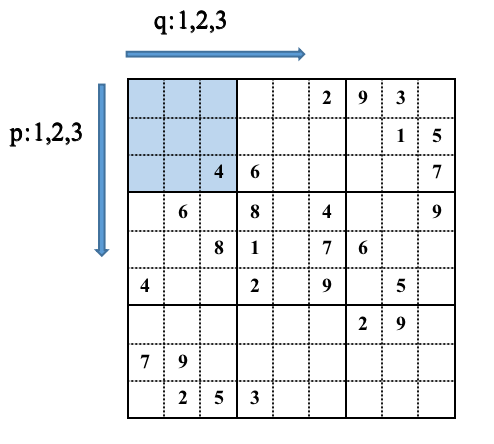

<center>图4：$p,q$控制宫在棋盘上的位置</center>

In [23]:
# Each value appears once per subgrid
model.addConstrs(x.sum(range(p*3, (p+1)*3), range(q*3, (q+1)*3), k) == 1
    for k in range(9)
    for p in range(3)
    for q in range(3))
print("添加宫约束后，模型约束条件数量：",model.getAttr("rows"))

添加宫约束后，模型约束条件数量： 352


这里$p$和$q$是用来控制数独棋盘中**宫**的位置移动，其中$p$控制宫在行方向上的移动，$q$控制宫在列方向上的移动。

例如，当$p=1$,$q=1$时，对应宫在棋盘上的位置为左上角蓝色区域。

另一种实现方式，多层循环嵌套：
```python
model.addConstrs(
    quicksum(x[i, j, k] for i in range(p*3, (p+1)*3) for j in range(q*3, (q+1)*3)) == 1
    for k in range(9)
    for p in range(3)
    for q in range(3))
```

## 5. 求解及可视化展示

### 5.1 求解并获取结果

In [25]:
model.solve()

Model fingerprint: 623eacda

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    352 rows, 729 columns and 2944 non-zero elements
    729 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

Problem was solved during presolve

Best solution   : 0.000000000
Best bound      : 0.000000000
Best gap        : 0.0000%
Solve time      : 0.01
Solve node      : 0
MIP status      : solved
Solution status : integer optimal (relative gap limit 0.0001)

Violations      :     absolute     relative
    bounds      :            0            0
    rows        :            0            0
    integrality :            0


### 5.2 可视化数独求解结果

In [27]:
# 可视化数独求解结果

sudoku_solution = SUDOKU_BOARD.copy()
for i in range(9):
    for j in range(9):
        for k in range(9):
            if x[i,j,k].x > 0:
                sudoku_solution[i,j] = k+1
                
print_board(sudoku_solution)

|8 1 7|5 4 2|9 3 6|
|2 3 9|7 8 6|4 1 5|
|5 4 6|9 1 3|8 2 7|
-------------------
|1 6 2|8 5 4|3 7 9|
|9 5 8|1 3 7|6 4 2|
|4 7 3|2 6 9|1 5 8|
-------------------
|3 8 4|6 7 5|2 9 1|
|7 9 1|4 2 8|5 6 3|
|6 2 5|3 9 1|7 8 4|


由于二维矩阵`SUDOKU_BOARD[i][j]`的取值为1~9，而决策变量`x[i,j,k]`中表示数字的下标k取值为\[0, 8\]。因此在对求解结果进行可视化输出时，`sudoku_solution[i,j] = k+1`